In [1]:
import sys
import os
import gymnasium as gym
from stable_baselines3 import DQN
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from shared_core_config import make_env
from src.evaluate import evaluate_policy

c:\Users\clemm\miniconda3\envs\project-rl-env\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Evaluating ../models/sb3/seed_1/dqn_sb3_final_seed_1 over 50 episodes...


Evaluating policy: 100%|██████████| 50/50 [02:46<00:00,  3.33s/it]


Mean Reward: 16.87 +/- 8.69
Crash Rate: 82.0%
Number of crashed episodes: 41
First few failed seeds (for video recording later): [100, 101, 103, 104, 105]


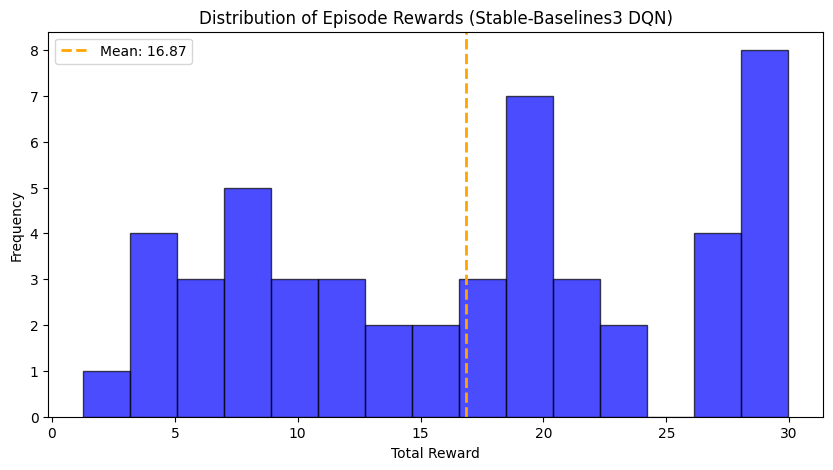

In [3]:
model_file = "../models/sb3/seed_1/dqn_sb3_final_seed_1"
if os.path.exists(model_file + ".zip"):
    env = make_env()
    try:
        model = DQN.load(model_file, env=env)
        
        policy_fn = lambda obs: model.predict(obs, deterministic=True)[0]
        
        print(f"Evaluating {model_file} over 50 episodes...")
        
        rewards, lengths, mean_r, std_r, crash_rate, failure_seeds = evaluate_policy(
            env, 
            policy_func=policy_fn, 
            num_episodes=50
        )
        
        print(f"Mean Reward: {mean_r:.2f} +/- {std_r:.2f}")
        print(f"Crash Rate: {crash_rate}%")
        print(f"Number of crashed episodes: {len(failure_seeds)}")
        if failure_seeds:
            print(f"First few failed seeds (for video recording later): {failure_seeds[:5]}")
            
        plt.figure(figsize=(10, 5))
        plt.hist(rewards, bins=15, color='blue', alpha=0.7, edgecolor='black')
        plt.title("Distribution of Episode Rewards (Stable-Baselines3 DQN)")
        plt.xlabel("Total Reward")
        plt.ylabel("Frequency")
        plt.axvline(mean_r, color='orange', linestyle='dashed', linewidth=2, label=f'Mean: {mean_r:.2f}')
        plt.legend()
        plt.show()
    finally:
        env.close()

else:
    print(f"Model file not found at {model_file}. Train the agent first.")